# 🌍 Phase 3 – Fault Line Data Integration  
**Notebook:** `3_fault_lines_integration.ipynb`

This notebook loads and processes fault line shapefiles from the **USGS Quaternary Faults Database** to engineer geospatial features for seismic risk modeling.  
These features are merged with the county-level dataset from Phase 2 to capture **proximity and exposure to active faults**, enriching the earthquake insurance risk analysis.

---

### 📦 Data Source  
- **USGS Quaternary Faults**: [https://earthquake.usgs.gov/static/lfs/nshm/qfaults/qfaults.zip](https://earthquake.usgs.gov/static/lfs/nshm/qfaults/qfaults.zip)  
- **Format**: ESRI Shapefile (.shp)  
- **Coverage**: Western U.S. (subset: California)

---

### 🎯 Feature Engineering Goals  
- ✅ **County–Fault Line Intersection** (`intersects_fault`, `n_faults_intersecting`, `faults_list`)  
- ✅ **Distance from County Centroid to Nearest Fault Line** (`centroid_to_fault_km`)  
- ✅ **Distance from County Edge to Nearest Fault Line** (`nearest_fault_km`)  
- ✅ **Total Fault Length Within Each County** (`fault_length_km`)  
- ✅ **Fault Orientation or Strike Direction Summary** (`mean_fault_azimuth_deg`, `fault_orientation`)

---

### 📤 Output  
The final GeoDataFrame `gdf_ca_extended_v3` includes the engineered fault features and is saved as:  
`../output/gdf_ca_extended_v3.geojson`

This enriched dataset will serve as input for Phase 4 modeling and dashboarding.

---
## 📦 Load Packages


In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np


---
## 📂 Data Loading

Load the following datasets to begin fault line integration:

- **`gdf_ca_extended`** – the extended California counties GeoDataFrame with demographics, housing, and insurance variables from **Phase 2**
- **`gdf_faults`** – onshore fault line segments from the **USGS Quaternary Faults Database**, covering the western U.S. (filtered to California)
- **`gdf_faults_offshore`** – offshore fault segments along the California coast (separate shapefile)


In [4]:
# Load Extended County GeoDataFrame (Demographics + Housing + Insurance)
gdf_ca_extended = gpd.read_file("../output/gdf_ca_extended_v2.geojson")
print(f"Loaded extended GeoDataFrame with {len(gdf_ca_extended)} counties")

gdf_ca_extended.head()


Loaded extended GeoDataFrame with 58 counties


,STATEFP,COUNTYFP,COUNTYNS,GEOID,GEOIDFQ,county,NAMELSAD,LSAD,CLASSFP,MTFCC,...,Direct_Insured_PML_2018,Modeled_Loss_Ratio_2018_pct,New_Voluntary,Renewed_Voluntary,New_FAIR,Renewed_FAIR,Total_Homeowners_Policies,homeowners_coverage_pct,fema_funding_earthquake,geometry
0,06,091,00277310,06091,0500000US06091,Sierra,Sierra County,06,H1,G4020,...,203,7.000000,46.0,1029.0,99.0,271.0,1445.0,68.842306,227958.95,"POLYGON ((-120.55587 39.50874, -120.55614 39.5..."
1,06,067,00277298,06067,0500000US06067,Sacramento,Sacramento County,06,H1,G4020,...,6631,11.689319,39427.0,375745.0,345.0,385.0,415902.0,70.062465,44911.70,"POLYGON ((-121.43991 38.25553, -121.44002 38.2..."
2,06,083,00277306,06083,0500000US06083,Santa Barbara,Santa Barbara County,06,H1,G4020,...,7076,7.565730,7184.0,84607.0,893.0,2299.0,94983.0,59.451323,648440.19,"MULTIPOLYGON (((-120.58226 34.10752, -120.5790..."
3,06,009,01675885,06009,0500000US06009,Calaveras,Calaveras County,06,H1,G4020,...,6631,11.689319,792.0,14025.0,2081.0,6270.0,23168.0,84.005947,NaN,"POLYGON ((-120.6318 38.34603, -120.63066 38.34..."
4,06,111,00277320,06111,0500000US06111,Ventura,Ventura County,06,H1,G4020,...,7076,7.565730,14637.0,177372.0,1842.0,2708.0,196559.0,66.709090,NaN,"MULTIPOLYGON (((-119.63607 33.28071, -119.6348..."


In [5]:
# Load the fault lines shapefile (USGS Quaternary Faults)
gdf_faults = gpd.read_file("../data/Qfaults_GIS/Qfaults_US_Database.shp")
print(f"Loaded {len(gdf_faults)} fault segments")
print(f"CRS: {gdf_faults.crs}")

gdf_faults.sample(5)


Loaded 112809 fault segments
CRS: EPSG:4326


,fault_name,section_na,fault_id,section_id,Location,linetype,age,dip_direct,slip_rate,slip_sense,...,strike,fault_leng,cooperator,earthquake,review_dat,fault_url,symbology,ref_id,Shape_Leng,geometry
23458,San Jacinto fault,Borrego Mountain section,125,e,California,Well Constrained,historic,Vertical,Between 1.0 and 5.0 mm/yr,Right lateral,...,None,244,California Geological Survey,Borrego Mountain earthquake,1999-03-01,https://earthquake.usgs.gov/cfusion/qfault/sho...,historic Well Constrained,125e,300.875516,"LINESTRING (-116.01001 33.03598, -116.01023 33..."
94672,Southern Sierra Nevada fault zone,Independence section,65,a,California,Well Constrained,latest Quaternary,E,Between 0.2 and 1.0 mm/yr,Normal,...,N19°W,203,California Geological Survey,None,1995-10-01,https://earthquake.usgs.gov/cfusion/qfault/sho...,latest Quaternary Well Constrained,65a,301.316745,"LINESTRING (-118.17583 36.56673, -118.17582 36..."
12485,Helendale-South Lockhart fault zone,South Lockhart section,110,a,California,Well Constrained,latest Quaternary,Vertical,Between 0.2 and 1.0 mm/yr,Right lateral,...,N27°W,135,California Geological Survey,None,2002-04-06,https://earthquake.usgs.gov/cfusion/qfault/sho...,latest Quaternary Well Constrained,110a,37.237652,"LINESTRING (-117.47073 35, -117.47055 34.99976)"
102028,Cascadia fold and fault belt,None,784,None,WA Offshore,Moderately Constrained,undifferentiated Quaternary,Vertical,Between 1.0 and 5.0 mm/yr,Thrust,...,N30°W,484,Washington Department of Natural Resources,None,2002-04-19,https://earthquake.usgs.gov/cfusion/qfault/sho...,undifferentiated Quaternary Moderately Constra...,784,4227.057262,"LINESTRING (-124.80048 48.31598, -124.76711 48..."
106911,San Gabriel fault zone,Honor Rancho section,89,b,California,Inferred,late Quaternary,Unspecified,Between 0.2 and 1.0 mm/yr,Right lateral,...,None,0,California Geological Survey,None,2017-05-15,https://earthquake.usgs.gov/cfusion/qfault/sho...,late Quaternary Inferred,89b,93.786388,"LINESTRING (-118.57456 34.44302, -118.5751 34...."


In [6]:
# Load offshore faults
gdf_faults_offshore = gpd.read_file("../data/Qfaults_GIS/ca_offshore.shp")
print(f"Loaded {len(gdf_faults_offshore)} offshore fault segments")
print(f"CRS: {gdf_faults_offshore.crs}")

gdf_faults_offshore.head()


Loaded 1093 offshore fault segments
CRS: EPSG:4326


,FAULT_NAME,FAULT_ZONE,SECTION_NA,OTHER_NAME,FAULT_ID,FLT_AGE,SLIP_RATE,SLIP_SENSE,SHAPE_LENG,MAPPED_SCA,LINE_TYPE,EXPRESSION,FLT_SOURCE,Location,Section_ID,geometry
0,San Gregorio-Hosgri fault zone,San Gregorio-Hosgri fault zone,South section,Hosgri fault,81,latest Quaternary,1-5,D,1.010,"1:35,000",Accurately Located,"bathy, high-res seismic (0.8,1 km), low-res se...","Golden, 2013; Hanson and Lettis, 1994; Johnson...",CA offshore,None,"LINESTRING (-121.04302 35.42581, -121.03708 35..."
1,San Gregorio-Hosgri fault zone,San Gregorio-Hosgri fault zone,South section,Hosgri fault,81,latest Quaternary,1-5,D,1.585,"1:35,000",Accurately Located,"bathy, high-res seismic (0.8,1 km), low-res se...","Golden, 2013; Hanson and Lettis, 1994; Johnson...",CA offshore,None,"LINESTRING (-121.03427 35.42869, -121.02298 35..."
2,San Gregorio-Hosgri fault zone,San Gregorio-Hosgri fault zone,South section,Hosgri fault,81,latest Quaternary,1-5,D,2.998,"1:35,000",Accurately Located,"bathy, high-res seismic (0.8,1 km), low-res se...","Golden, 2013; Hanson and Lettis, 1994; Johnson...",CA offshore,None,"LINESTRING (-121.04336 35.44028, -121.04069 35..."
3,San Gregorio-Hosgri fault zone,San Gregorio-Hosgri fault zone,South section,Hosgri fault,81,latest Quaternary,1-5,D,3.606,"1:35,000",Accurately Located,"bathy, high-res seismic (0.8,1 km), low-res se...","Golden, 2013; Hanson and Lettis, 1994; Johnson...",CA offshore,None,"LINESTRING (-121.06068 35.45753, -121.05807 35..."
4,San Gregorio-Hosgri fault zone,San Gregorio-Hosgri fault zone,South section,Hosgri fault,81,latest Quaternary,1-5,D,3.072,"1:35,000",Accurately Located,"bathy, high-res seismic (0.8,1 km), low-res se...","Golden, 2013; Hanson and Lettis, 1994; Johnson...",CA offshore,None,"LINESTRING (-121.05713 35.46756, -121.05419 35..."


---
## 🧼 Fault Data Cleaning & Preparation

Steps taken to clean and prepare fault line data:

- Filtered to **California-only segments** using the `Location` column  
- Dropped unnecessary metadata columns  
- Normalized the `age` field and retained only **active faults** (`Historic`, `Latest Quaternary`, etc.)  
- Reprojected geometries to **EPSG:3310** for accurate distance and area calculations  
- Computed geometric lengths of each segment (`geom_length_km`)  
- Aggregated segments into one row per fault (`gdf_faults_ca_dissolved`) with total fault length (`total_geom_km`)  
- Joined total fault lengths back to the original segment-level dataset for further analysis

---
### 🔍 Inspect `gdf_faults`


In [8]:
# Check available columns & unique counts
gdf_faults.info()


<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 112809 entries, 0 to 112808
Data columns (total 23 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   fault_name  112809 non-null  object        
 1   section_na  46584 non-null   object        
 2   fault_id    112809 non-null  object        
 3   section_id  47066 non-null   object        
 4   Location    112809 non-null  object        
 5   linetype    112809 non-null  object        
 6   age         112809 non-null  object        
 7   dip_direct  109984 non-null  object        
 8   slip_rate   109119 non-null  object        
 9   slip_sense  106025 non-null  object        
 10  scale       112809 non-null  object        
 11  class       110718 non-null  object        
 12  certainty   100363 non-null  object        
 13  strike      88151 non-null   object        
 14  fault_leng  112809 non-null  int64         
 15  cooperator  112809 non-null  object        

In [9]:
# Quick overview of key descriptive columns
gdf_faults[['fault_name', 'section_na', 'fault_id', 'section_id', 'ref_id', 'Location', 'age', 'slip_rate', 'slip_sense', 'dip_direct', 'fault_leng', 'Shape_Leng', 'geometry']].head(10)


,fault_name,section_na,fault_id,section_id,ref_id,Location,age,slip_rate,slip_sense,dip_direct,fault_leng,Shape_Leng,geometry
0,Goose Lake graben faults (Goose Lake fault),None,828,None,828,California,late Quaternary,Less than 0.2 mm/yr,Normal,W,0,4804.373592,"LINESTRING (-120.28499 41.89968, -120.27027 41..."
1,Goose Lake graben faults (Goose Lake fault),None,828,None,828,California,late Quaternary,Less than 0.2 mm/yr,Normal,W,0,7612.099182,"LINESTRING (-120.20135 41.84413, -120.22774 41..."
2,Goose Lake graben faults (Goose Lake fault),None,828,None,828,California,late Quaternary,Less than 0.2 mm/yr,Normal,W,0,1697.722844,"LINESTRING (-120.21119 41.81342, -120.20457 41..."
3,Goose Lake graben faults (Goose Lake fault),None,828,None,828,California,late Quaternary,Less than 0.2 mm/yr,Normal,W,0,7135.032834,"LINESTRING (-120.20135 41.84413, -120.1965 41...."
4,Goose Lake graben faults (Goose Lake fault),None,828,None,828,California,late Quaternary,Less than 0.2 mm/yr,Normal,W,0,3022.325115,"LINESTRING (-120.19371 41.82478, -120.19589 41..."
5,Goose Lake graben faults (Goose Lake fault),None,828,None,828,California,late Quaternary,Less than 0.2 mm/yr,Normal,W,0,1671.102965,"LINESTRING (-120.18143 41.83778, -120.17885 41..."
6,Mayfield fault zone,None,6,None,6,California,late Quaternary,Between 1.0 and 5.0 mm/yr,Normal,W,32,3908.362836,"LINESTRING (-121.46978 41.2388, -121.47327 41...."
7,unnamed Fault in the Little San Bernardino Mou...,None,213,None,213,California,latest Quaternary,Unspecified,None,None,0,2650.726646,"LINESTRING (-116.34005 33.9148, -116.33528 33...."
8,San Andreas fault zone,Shelter Cove Section,1,a,1a,California,historic,Greater than 5.0 mm/yr,Right lateral,Vertical,1082,8505.454600,"LINESTRING (-124.07161 40.06145, -124.08192 40..."
9,San Andreas fault zone,Shelter Cove Section,1,a,1a,California,historic,Greater than 5.0 mm/yr,Right lateral,Vertical,1082,312.395544,"LINESTRING (-124.078 40.04641, -124.07949 40.0..."


In [10]:
# Frequency counts for key fields
print("Unique fault names:", gdf_faults['fault_name'].nunique())
print("\nTop fault names:")
print(gdf_faults['fault_name'].value_counts().head(15))


Unique fault names: 2107

Top fault names:
fault_name
San Andreas fault zone             8042
San Jacinto fault                  3306
Garlock fault zone                 2185
Unnamed fault in California        1379
Homestead Valley fault zone        1371
Owens Valley fault zone            1350
Coachella Fan Fault Zone           1260
Sierra Madre fault zone            1247
Alamogordo fault                   1189
San Felipe fault zone              1133
Elsinore fault zone                1113
Southern Sangre de Cristo fault    1072
Johnson Valley fault zone           938
Panamint Valley fault zone          896
San Gabriel fault zone              768
Name: count, dtype: int64


In [11]:
# Check locations
gdf_faults['Location'].value_counts()


Location
California     59491
Nevada         18076
New Mexico     16189
Utah            4561
Oregon          3823
Washington      2098
Arizona         1846
Wyoming         1747
Alaska          1501
Hawaii           899
Colorado         747
Idaho            719
WA Offshore      474
Texas            380
Montana          234
Oklahoma          23
Kansas             1
Name: count, dtype: int64

In [12]:
# Keep only named faults located in California
gdf_faults_ca = gdf_faults[
    (gdf_faults["Location"] == "California") &
    gdf_faults["fault_name"].notna() &
    (gdf_faults["fault_name"].str.strip() != "") &
    ~gdf_faults["fault_name"].str.lower().str.startswith("unnamed")
].copy()

print(f"Named fault segments located in California: {len(gdf_faults_ca):,}")
print("Unique fault names in California:", gdf_faults_ca['fault_name'].nunique())


Named fault segments located in California: 55,002
Unique fault names in California: 475


In [13]:
# Define essential columns to keep for feature engineering or inspection
columns_to_keep = [
    "fault_name",     # Name of the fault zone
    "section_na",     # Optional subzone (sometimes used)
    "fault_id",       # Unique identifier
    "section_id",     # Optional segment ID
    "age",            # Fault age (e.g. Holocene, Quaternary)
    "slip_rate",      # Textual slip rate info
    "slip_sense",     # Movement direction (e.g. strike-slip)
    "dip_direct",     # Dip direction (e.g. W, NW)
    "class",          # USGS quality class
    "certainty",      # Fault certainty classification
    "fault_leng",     # Metadata-based fault length (km?)
    "geometry"        # Required for spatial ops
]

# Subset and clean
gdf_faults_ca = gdf_faults_ca[columns_to_keep].copy()
gdf_faults_ca.reset_index(drop=True, inplace=True)

# Confirm
print(f"Filtered California fault segments: {len(gdf_faults_ca):,}")
gdf_faults_ca.head()


Filtered California fault segments: 55,002


,fault_name,section_na,fault_id,section_id,age,slip_rate,slip_sense,dip_direct,class,certainty,fault_leng,geometry
0,Goose Lake graben faults (Goose Lake fault),None,828,None,late Quaternary,Less than 0.2 mm/yr,Normal,W,A,Good,0,"LINESTRING (-120.28499 41.89968, -120.27027 41..."
1,Goose Lake graben faults (Goose Lake fault),None,828,None,late Quaternary,Less than 0.2 mm/yr,Normal,W,A,Good,0,"LINESTRING (-120.20135 41.84413, -120.22774 41..."
2,Goose Lake graben faults (Goose Lake fault),None,828,None,late Quaternary,Less than 0.2 mm/yr,Normal,W,A,Good,0,"LINESTRING (-120.21119 41.81342, -120.20457 41..."
3,Goose Lake graben faults (Goose Lake fault),None,828,None,late Quaternary,Less than 0.2 mm/yr,Normal,W,A,Good,0,"LINESTRING (-120.20135 41.84413, -120.1965 41...."
4,Goose Lake graben faults (Goose Lake fault),None,828,None,late Quaternary,Less than 0.2 mm/yr,Normal,W,A,Good,0,"LINESTRING (-120.19371 41.82478, -120.19589 41..."


In [14]:
# Group detailed USGS age descriptions into simplified categories
def simplify_age(age):
    age = age.lower().strip() if isinstance(age, str) else ''
    
    if 'historic' in age:
        return 'Historic'
    elif 'latest quaternary' in age:
        return 'Latest Quaternary'
    elif 'middle and late' in age:
        return 'Middle & Late Quaternary'
    elif age in ['late quaternary', 'late quaternary ']:
        return 'Late Quaternary'
    elif 'undifferentiated' in age:
        return 'Undiff. Quaternary'
    elif 'class b' in age:
        return 'Class B'
    else:
        return 'Other/Unspecified'

# Add new column
gdf_faults_ca["age_grouped"] = gdf_faults_ca["age"].apply(simplify_age)

# Keep only active / recent faults
keep_ages = [
    "Latest Quaternary",
    "Historic",
    "Late Quaternary",
    "Middle & Late Quaternary"
]

gdf_faults_ca_active = gdf_faults_ca[
    gdf_faults_ca["age_grouped"].isin(keep_ages)
].copy()

# Drop original age column if no longer needed
gdf_faults_ca_active.drop(columns="age", inplace=True)

# Preview
print(f"Remaining active fault segments: {len(gdf_faults_ca_active):,}")
gdf_faults_ca_active[["fault_name", "age_grouped"]].sample(10)


Remaining active fault segments: 45,882


,fault_name,age_grouped
45974,Rinconada fault zone,Late Quaternary
36738,Banning fault,Latest Quaternary
7136,San Andreas fault zone,Late Quaternary
22851,Southern Death Valley fault zone,Latest Quaternary
17878,San Jacinto fault,Latest Quaternary
23380,Warm Springs Valley fault zone,Latest Quaternary
46194,Quien Sabe fault,Latest Quaternary
23799,Nelson Corral fault,Late Quaternary
23788,Lake City fault zone,Latest Quaternary
27711,Pine Mountain fault,Late Quaternary


In [15]:
# Count of unique active fault names retained after filtering (onshore only)
gdf_faults_ca_active["fault_name"].nunique()
print("Unique active onshore fault names:", gdf_faults_ca_active["fault_name"].nunique())


Unique active onshore fault names: 288


In [16]:
# Reproject to meters
gdf_faults_ca_active = gdf_faults_ca_active.to_crs("EPSG:3310")

# Compute accurate geometric length in kilometers
gdf_faults_ca_active["geom_length_km"] = gdf_faults_ca_active.geometry.length / 1000

# Group to get total length per fault
fault_length_by_name = (
    gdf_faults_ca_active
    .groupby("fault_name")["geom_length_km"]
    .sum()
    .rename("fault_total_km")
    .reset_index()
)

# Merge back to original dataset
gdf_faults_ca_active = gdf_faults_ca_active.merge(
    fault_length_by_name,
    on="fault_name",
    how="left"
)


In [17]:
# Preview
gdf_faults_ca_active[["fault_name", "fault_leng", "geom_length_km", "fault_total_km"]].sample(5)


,fault_name,fault_leng,geom_length_km,fault_total_km
17971,San Jacinto fault,244,0.030483,1101.594230
25826,Coachella Fan Fault Zone,0,0.179598,105.050097
110,San Andreas fault zone,1082,0.108990,3101.569651
34643,Owens Valley fault zone,136,2.552202,464.956046
17796,San Jacinto fault,244,0.036554,1101.594230


In [18]:
# Dissolve by fault_name
gdf_faults_ca_dissolved = gdf_faults_ca_active[["fault_name", "geometry"]].dissolve(by="fault_name").reset_index()

# Add total geometric length
gdf_faults_ca_dissolved["total_geom_km"] = gdf_faults_ca_dissolved.geometry.length / 1000

print(f"🔹 Dissolved onshore faults: {len(gdf_faults_ca_dissolved)} names")
gdf_faults_ca_dissolved.sort_values("total_geom_km", ascending=False).head(10)


🔹 Dissolved onshore faults: 288 names


,fault_name,geometry,total_geom_km
220,San Andreas fault zone,"MULTILINESTRING ((-347126.289 234739.906, -347...",3101.168155
228,San Jacinto fault,"MULTILINESTRING ((241884.214 -432046.05, 24496...",1101.409535
81,Garlock fault zone,"MULTILINESTRING ((181007.743 -302672.118, 1810...",812.785089
71,Elsinore fault zone,"MULTILINESTRING ((182171.889 -445592.232, 1818...",558.407654
184,Owens Valley fault zone,"MULTILINESTRING ((140461.67 -75859.2, 140472.4...",463.559693
245,Sierra Madre fault zone,"MULTILINESTRING ((109949.94 -403126.732, 10970...",386.632409
34,Calaveras fault zone,"MULTILINESTRING ((-165291.158 -46126.77, -1649...",343.939097
13,Bartlett Springs fault system,"MULTILINESTRING ((-290912.113 232696.238, -290...",316.900056
145,Mad River fault zone,"MULTILINESTRING ((-329212.858 319935.966, -329...",299.432049
40,Cedar Mountain fault system,"MULTILINESTRING ((-156068.735 430940.805, -155...",297.385004


---
### 🌊 Inspect `gdf_faults_offshore`


In [20]:
gdf_faults_offshore.info()


<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1093 entries, 0 to 1092
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   FAULT_NAME  1093 non-null   object  
 1   FAULT_ZONE  1093 non-null   object  
 2   SECTION_NA  370 non-null    object  
 3   OTHER_NAME  198 non-null    object  
 4   FAULT_ID    478 non-null    object  
 5   FLT_AGE     1093 non-null   object  
 6   SLIP_RATE   1093 non-null   object  
 7   SLIP_SENSE  1093 non-null   object  
 8   SHAPE_LENG  1093 non-null   float64 
 9   MAPPED_SCA  1093 non-null   object  
 10  LINE_TYPE   1093 non-null   object  
 11  EXPRESSION  1093 non-null   object  
 12  FLT_SOURCE  1093 non-null   object  
 13  Location    1093 non-null   object  
 14  Section_ID  73 non-null     object  
 15  geometry    1093 non-null   geometry
dtypes: float64(1), geometry(1), object(14)
memory usage: 136.8+ KB


In [21]:
# Rename columns to match the onshore dataset
gdf_faults_offshore_clean = gdf_faults_offshore.rename(columns={
    "FAULT_NAME": "fault_name",
    "SECTION_NA": "section_na",
    "FAULT_ID": "fault_id",
    "Section_ID": "section_id",
    "FLT_AGE": "age",
    "SLIP_RATE": "slip_rate",
    "SLIP_SENSE": "slip_sense",
    "SHAPE_LENG": "shape_length",
})

# Select only the matching/needed columns
columns_to_keep = [
    "fault_name", "section_na", "fault_id", "section_id",
    "age", "slip_rate", "slip_sense", "geometry"
]
gdf_faults_offshore_clean = gdf_faults_offshore_clean[columns_to_keep].copy()

# Reset index
gdf_faults_offshore_clean.reset_index(drop=True, inplace=True)

# Preview cleaned offshore dataset
print(f"Cleaned offshore faults: {len(gdf_faults_offshore_clean)} segments")
gdf_faults_offshore_clean.head()


Cleaned offshore faults: 1093 segments


,fault_name,section_na,fault_id,section_id,age,slip_rate,slip_sense,geometry
0,San Gregorio-Hosgri fault zone,South section,81,None,latest Quaternary,1-5,D,"LINESTRING (-121.04302 35.42581, -121.03708 35..."
1,San Gregorio-Hosgri fault zone,South section,81,None,latest Quaternary,1-5,D,"LINESTRING (-121.03427 35.42869, -121.02298 35..."
2,San Gregorio-Hosgri fault zone,South section,81,None,latest Quaternary,1-5,D,"LINESTRING (-121.04336 35.44028, -121.04069 35..."
3,San Gregorio-Hosgri fault zone,South section,81,None,latest Quaternary,1-5,D,"LINESTRING (-121.06068 35.45753, -121.05807 35..."
4,San Gregorio-Hosgri fault zone,South section,81,None,latest Quaternary,1-5,D,"LINESTRING (-121.05713 35.46756, -121.05419 35..."


In [22]:
# Apply simplify_age to offshore data
gdf_faults_offshore_clean["age_grouped"] = gdf_faults_offshore_clean["age"].apply(simplify_age)

# Define active ages
keep_ages = [
    "Latest Quaternary",
    "Historic",
    "Late Quaternary",
    "Middle & Late Quaternary"
]

# Filter for active faults
gdf_faults_offshore_active = gdf_faults_offshore_clean[
    gdf_faults_offshore_clean["age_grouped"].isin(keep_ages)
].copy()

# Preview
print(f"Active offshore faults: {len(gdf_faults_offshore_active)} segments")
gdf_faults_offshore_active["age_grouped"].value_counts()


Active offshore faults: 606 segments


age_grouped
Latest Quaternary    415
Historic             131
Late Quaternary       60
Name: count, dtype: int64

In [23]:
# Project to EPSG:3310 (California Albers for accurate distance)
gdf_faults_offshore_active_proj = gdf_faults_offshore_active.to_crs(epsg=3310)

# Calculate geometry length in kilometers
gdf_faults_offshore_active_proj["geom_length_km"] = (
    gdf_faults_offshore_active_proj.length / 1000
)

# Aggregate total length per fault name (grouped version)
offshore_grouped = (
    gdf_faults_offshore_active_proj
    .dissolve(by="fault_name", as_index=False)
    .assign(total_geom_km=lambda df: df.length / 1000)
    [["fault_name", "geometry", "total_geom_km"]]
)

# Preview
print(f"🔹 Dissolved offshore faults: {len(offshore_grouped)} names")
offshore_grouped.sort_values("total_geom_km", ascending=False).head(10)


🔹 Dissolved offshore faults: 35 names


,fault_name,geometry,total_geom_km
26,San Gregorio-Hosgri fault zone,"MULTILINESTRING ((-94616.06 -287381.219, -9408...",845.142542
23,San Andreas fault zone,"MULTILINESTRING ((-261318.508 30443.47, -26114...",351.033773
16,Palos Verdes fault zone,"MULTILINESTRING ((187929.055 -516874.341, 1882...",209.139964
24,San Clemente fault,"MULTILINESTRING ((208257.178 -628180.884, 2063...",178.939058
25,San Diego Trough fault zone,"MULTILINESTRING ((192728.479 -545254.633, 1923...",159.940089
3,East Monterey Bay fault zone,"MULTILINESTRING ((-178039.138 -128649.629, -17...",159.818001
12,Newport-Inglewood fault zone,"MULTILINESTRING ((207952.665 -501585.428, 2076...",135.169620
22,Rose Canyon fault zone,"MULTILINESTRING ((264285.363 -583377.815, 2641...",127.552737
15,Oak Ridge fault,"MULTILINESTRING ((67476.272 -419019.454, 65654...",98.157807
27,San Mateo fault zone,"MULTILINESTRING ((219804.815 -521751.497, 2191...",83.814985


---
### 🧬 Combine Onshore & Offshore Faults (Cleaned & Dissolved)

Active fault segments from both **onshore (USGS Quaternary Faults Database)** and **offshore (California Offshore Shapefile)** sources were merged and cleaned.  
After dissolving by `fault_name`, the result is a unified dataset of **315 distinct fault zones**, with total geometry lengths preserved.

✅ CRS: `EPSG:3310` (California Albers)  
✅ Dataset is ready for spatial intersection with counties and distance-based feature engineering


In [25]:
# Confirm both onshore and offshore datasets use the same projected CRS (EPSG:3310)
assert gdf_faults_ca_dissolved.crs == offshore_grouped.crs

# Combine dissolved onshore + offshore datasets
gdf_faults_combined_dissolved = pd.concat(
    [gdf_faults_ca_dissolved, offshore_grouped],
    ignore_index=True
)

# Quick check: number of combined fault zones and preview (sorted by total length)
print(f"Total combined faults: {len(gdf_faults_combined_dissolved)}")
gdf_faults_combined_dissolved.sort_values(by='total_geom_km')


Total combined faults: 323


,fault_name,geometry,total_geom_km
140,Loon Point fault,"MULTILINESTRING ((38275.679 -400038.207, 38291...",0.648176
180,Ortega Hill fault,"LINESTRING (35632.461 -399073.749, 35802.134 -...",1.016920
69,Edison fault,"MULTILINESTRING ((126103.005 -303606.115, 1262...",1.717656
219,Saddle Blanket Flat fault zone,"LINESTRING (-111070.127 402652.378, -110584.68...",2.094067
68,Echo Canyon thrust,"MULTILINESTRING ((284187.122 -170254.046, 2841...",2.394083
...,...,...,...
71,Elsinore fault zone,"MULTILINESTRING ((182171.889 -445592.232, 1818...",558.407654
81,Garlock fault zone,"MULTILINESTRING ((181007.743 -302672.118, 1810...",812.785089
314,San Gregorio-Hosgri fault zone,"MULTILINESTRING ((-94616.06 -287381.219, -9408...",845.142542
228,San Jacinto fault,"MULTILINESTRING ((241884.214 -432046.05, 24496...",1101.409535


In [26]:
# Keep only relevant columns
onshore = gdf_faults_ca_dissolved[["fault_name", "geometry"]]
offshore = offshore_grouped[["fault_name", "geometry"]]

# Concatenate both GeoDataFrames
faults_all = pd.concat([onshore, offshore], ignore_index=True)

# Dissolve again to unify same-name faults (e.g., San Andreas onshore + offshore)
gdf_faults_combined_final = faults_all.dissolve(by="fault_name").reset_index()

# Preview result
print(f"Final unified fault zones: {len(gdf_faults_combined_final)}")
gdf_faults_combined_final.head()


Final unified fault zones: 315


,fault_name,geometry
0,Adobe Creek fault,"MULTILINESTRING ((-249253.09 108680.881, -2489..."
1,Airport Lake fault zone,"MULTILINESTRING ((207307.798 -243353.662, 2073..."
2,Alexander-Redwood Hill fault zone,"MULTILINESTRING ((-256014.16 82743.231, -25703..."
3,Almanor fault zone,"MULTILINESTRING ((-105627.961 271165.638, -105..."
4,Amedee fault,"MULTILINESTRING ((-17079.145 253178.951, -1707..."


In [27]:
# Add total geometric length
gdf_faults_combined_final["total_geom_km"] = gdf_faults_combined_final.geometry.length / 1000

print(f"Dissolved faults: {len(gdf_faults_combined_final)} names")
gdf_faults_combined_final.sort_values("total_geom_km", ascending=False).head(10)


Dissolved faults: 315 names


,fault_name,geometry,total_geom_km
238,San Andreas fault zone,"MULTILINESTRING ((-347126.289 234739.906, -347...",3452.201928
249,San Jacinto fault,"MULTILINESTRING ((241884.214 -432046.05, 24496...",1101.409535
248,San Gregorio-Hosgri fault zone,"MULTILINESTRING ((-94616.06 -287381.219, -9408...",845.142542
85,Garlock fault zone,"MULTILINESTRING ((181007.743 -302672.118, 1810...",812.785089
75,Elsinore fault zone,"MULTILINESTRING ((182171.889 -445592.232, 1818...",558.407654
197,Owens Valley fault zone,"MULTILINESTRING ((140461.67 -75859.2, 140472.4...",463.559693
271,Sierra Madre fault zone,"MULTILINESTRING ((109949.94 -403126.732, 10970...",386.632409
34,Calaveras fault zone,"MULTILINESTRING ((-165291.158 -46126.77, -1649...",343.939097
13,Bartlett Springs fault system,"MULTILINESTRING ((-290912.113 232696.238, -290...",316.900056
152,Mad River fault zone,"MULTILINESTRING ((-329212.858 319935.966, -329...",299.432049


In [28]:
# Sum of dissolved (merged) faults
total_dissolved_km = gdf_faults_combined_final["total_geom_km"].sum()

# Sum of raw undissolved segments
total_undissolved_km = gdf_faults_ca_active["geom_length_km"].sum() + offshore_grouped["total_geom_km"].sum()

# Comparison output
print(f"Total (Dissolved): {total_dissolved_km:,.2f} km")
print(f"Total (Undissolved Segments): {total_undissolved_km:,.2f} km")
print(f"Difference: {total_undissolved_km - total_dissolved_km:.2f} km")


Total (Dissolved): 25,462.09 km
Total (Undissolved Segments): 25,471.49 km
Difference: 9.39 km


In [29]:
# Save cleaned active onshore fault segments
gdf_faults_ca_active.to_file("../data/faults_ca_active.geojson", driver="GeoJSON")

# Save final combined onshore + offshore dissolved fault zones
gdf_faults_combined_final.to_file("../data/faults_ca_combined.geojson", driver="GeoJSON")


---
## 🗺️ Visualization

Three reference plots were created to support geospatial interpretation:

- **Onshore Fault Segments** – visualized active, named fault segments across California  
- **Color-Coded Fault Zones** – displayed a full-state map of both onshore and offshore fault zones, styled by name (no legend; contextual overview)  
- **Top 10 Longest Fault Zones** – highlighted and labeled the ten longest fault zones by total geometric length  


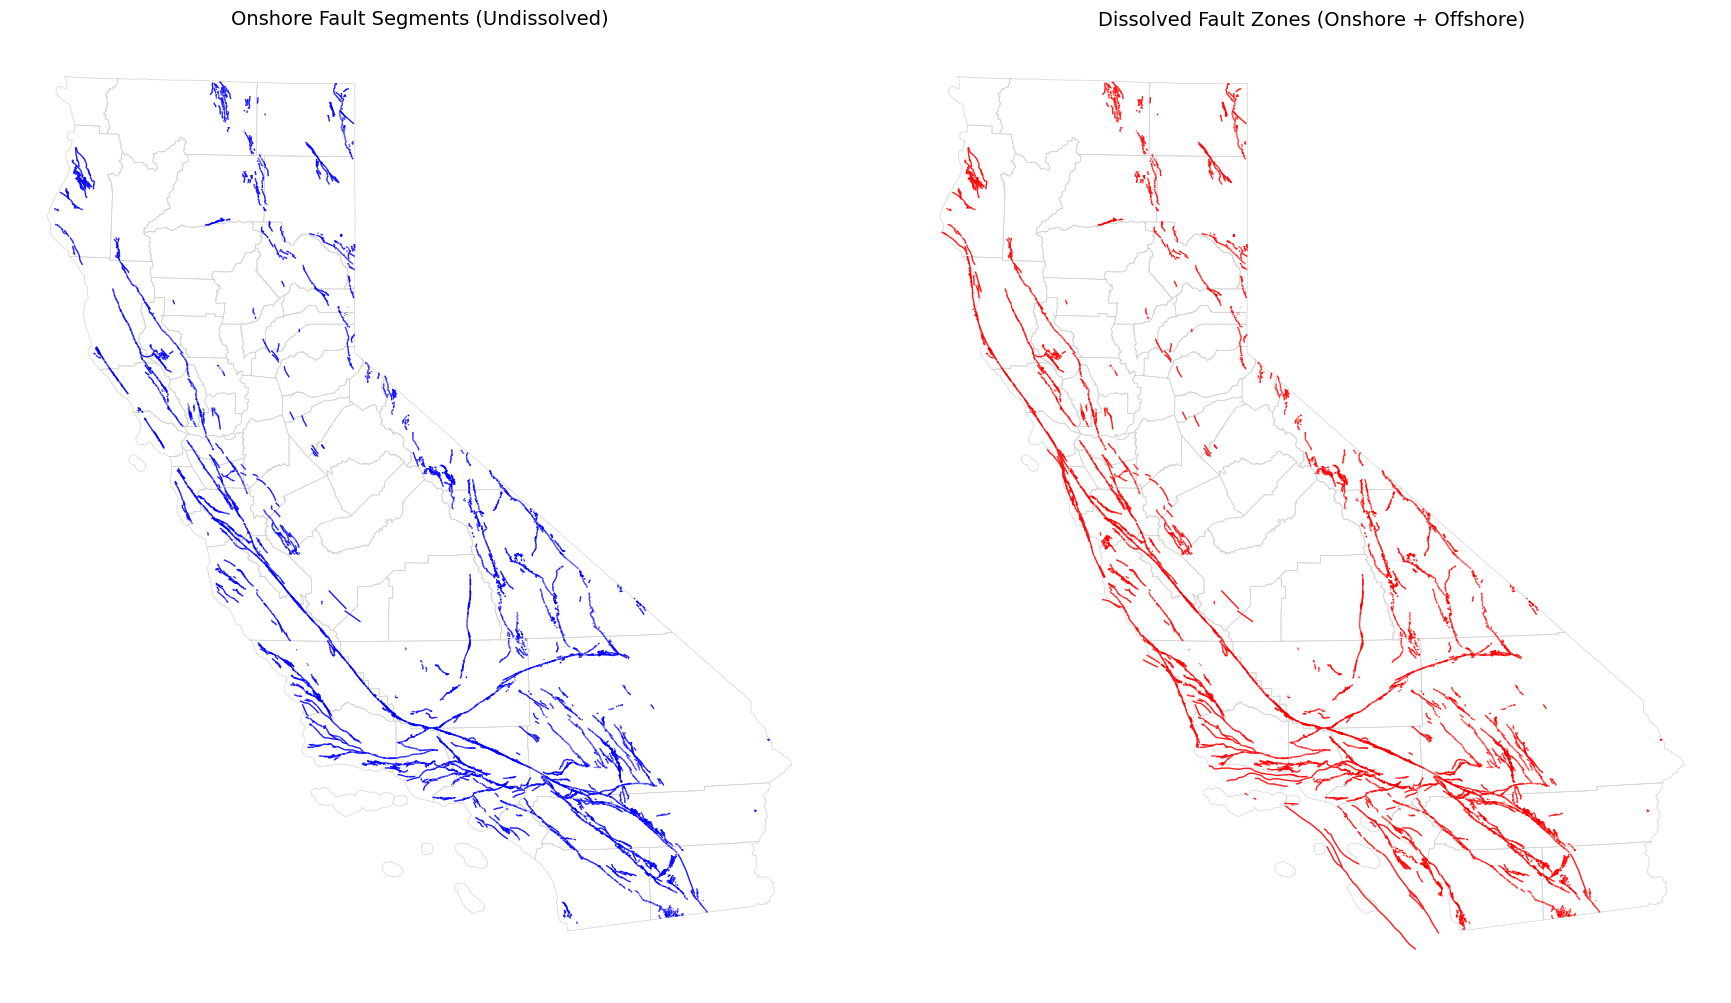

In [31]:
# Reproject counties for context
gdf_ca_3310 = gdf_ca_extended.to_crs("EPSG:3310")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 10), sharex=True, sharey=True)

# County boundaries for context
gdf_ca_3310.boundary.plot(ax=ax1, linewidth=0.5, color="lightgray")
gdf_ca_3310.boundary.plot(ax=ax2, linewidth=0.5, color="lightgray")

# Left: Onshore fault segments 
gdf_faults_ca_active.plot(ax=ax1, color="blue", linewidth=1.0, alpha=0.9)
ax1.set_title("Onshore Fault Segments (Undissolved)", fontsize=14)
ax1.set_axis_off()

# Right: Combined dissolved fault zones
gdf_faults_combined_final.plot(ax=ax2, color="red", linewidth=1.0, alpha=0.9)
ax2.set_title("Dissolved Fault Zones (Onshore + Offshore)", fontsize=14)
ax2.set_axis_off()

plt.tight_layout()
plt.show()


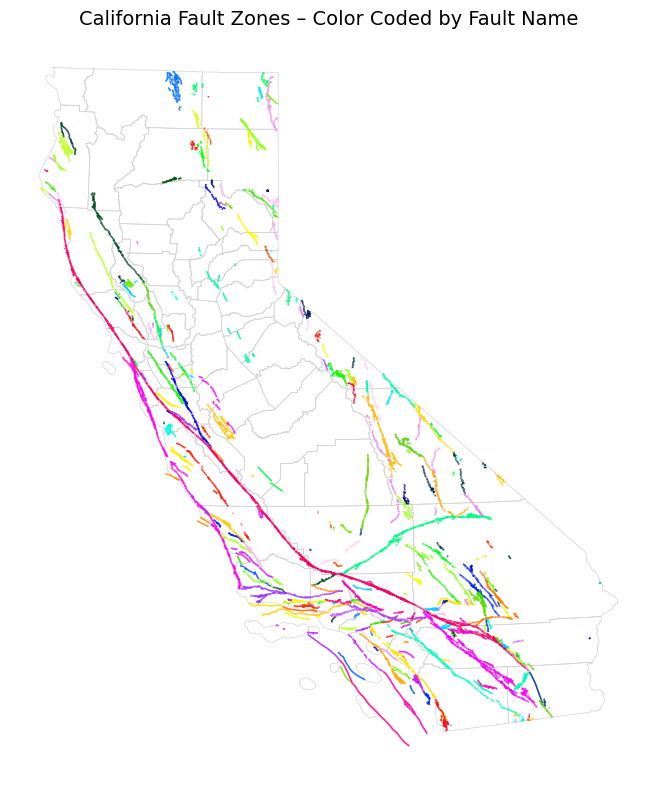

In [32]:
fig, ax = plt.subplots(figsize=(8, 8)) 

# Plot counties for geographic context
gdf_ca_3310.boundary.plot(ax=ax, color="lightgray", linewidth=0.5)

# Plot dissolved fault zones (color-coded by name)
gdf_faults_combined_final.plot(
    ax=ax,
    column="fault_name",
    cmap="gist_ncar",
    legend=False,  
    linewidth=1.2,
    alpha=0.85
)

# Title and layout
ax.set_title("California Fault Zones – Color Coded by Fault Name", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("../output/california_fault_zones.png", dpi=300, bbox_inches="tight")
plt.show()


In [33]:
# Top 10 by total fault length (already calculated)
top10_faults = gdf_faults_combined_final.nlargest(10, "total_geom_km").copy()
top10_faults[['fault_name', 'total_geom_km']]


,fault_name,total_geom_km
238,San Andreas fault zone,3452.201928
249,San Jacinto fault,1101.409535
248,San Gregorio-Hosgri fault zone,845.142542
85,Garlock fault zone,812.785089
75,Elsinore fault zone,558.407654
197,Owens Valley fault zone,463.559693
271,Sierra Madre fault zone,386.632409
34,Calaveras fault zone,343.939097
13,Bartlett Springs fault system,316.900056
152,Mad River fault zone,299.432049


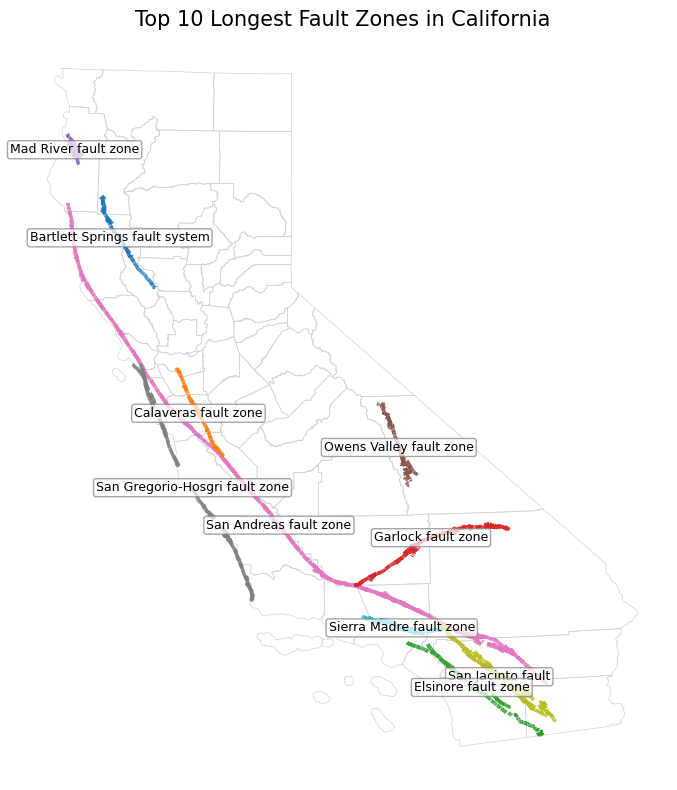

In [34]:
fig, ax = plt.subplots(figsize=(8, 8))

# Background counties
gdf_ca_3310.boundary.plot(ax=ax, color="lightgray", linewidth=0.5)

# Top 10 fault lines
top10_faults.plot(
    ax=ax,
    column="fault_name",
    cmap="tab10",  
    linewidth=2.5,
    legend=False,
    alpha=0.9
)

# Add fault name labels
for idx, row in top10_faults.iterrows():
    label_point = row.geometry.representative_point()
    ax.text(
        label_point.x,
        label_point.y,
        row.fault_name,
        fontsize=9,
        ha="center",
        va="center",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.7)
    )

# Title and layout
ax.set_title("Top 10 Longest Fault Zones in California", fontsize=15)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("../output/top10_fault_zones.png", dpi=300, bbox_inches="tight")
plt.show()


---
## 🧮 Feature Engineering Step: Fault–County Relationships

---
### County–Fault Intersection Feature

County–fault intersections were computed to identify which faults cross each county.  
For each county, I aggregated the results into the following features:

- `intersects_fault`: Boolean indicator of whether a county intersects at least one fault  
- `n_faults_intersecting`: Number of distinct fault zones intersecting the county  
- `faults_list`: List of intersecting fault names  


In [36]:
# Reproject faults to match counties
gdf_faults_combined_final = gdf_faults_combined_final.to_crs(gdf_ca_extended.crs)

# Perform spatial join on intersection
gdf_intersections = gpd.sjoin(
    gdf_ca_extended,
    gdf_faults_combined_final[["fault_name", "geometry"]],
    how="left",
    predicate="intersects"
)

# Preview intersecting county-fault pairs
gdf_intersections[["county", "fault_name"]].dropna().head(10)


,county,fault_name
0,Sierra,Mohawk Valley fault zone
0,Sierra,Polaris fault
0,Sierra,Dog Valley fault zone
0,Sierra,Upper Long Valley fault zone
2,Santa Barbara,Santa Cruz Island fault zone
2,Santa Barbara,Red Mountain fault
2,Santa Barbara,Red Mountain fault zone
2,Santa Barbara,North Channel-Pitas Point fault
2,Santa Barbara,Shepard Mesa fault
2,Santa Barbara,Isla Vista fault


In [37]:
# Group by county → collect intersected faults
faults_by_county = (
    gdf_intersections
    .dropna(subset=["fault_name"])
    .groupby("county")["fault_name"]
    .agg(["nunique", list])
    .rename(columns={"nunique": "n_faults_intersecting", "list": "faults_list"})
)

# Merge into main counties GeoDataFrame
gdf_ca_extended = gdf_ca_extended.merge(
    faults_by_county,
    on="county",
    how="left"
)

gdf_ca_extended.head()


,STATEFP,COUNTYFP,COUNTYNS,GEOID,GEOIDFQ,county,NAMELSAD,LSAD,CLASSFP,MTFCC,...,New_Voluntary,Renewed_Voluntary,New_FAIR,Renewed_FAIR,Total_Homeowners_Policies,homeowners_coverage_pct,fema_funding_earthquake,geometry,n_faults_intersecting,faults_list
0,06,091,00277310,06091,0500000US06091,Sierra,Sierra County,06,H1,G4020,...,46.0,1029.0,99.0,271.0,1445.0,68.842306,227958.95,"POLYGON ((-120.55587 39.50874, -120.55614 39.5...",4.0,"[Mohawk Valley fault zone, Polaris fault, Dog ..."
1,06,067,00277298,06067,0500000US06067,Sacramento,Sacramento County,06,H1,G4020,...,39427.0,375745.0,345.0,385.0,415902.0,70.062465,44911.70,"POLYGON ((-121.43991 38.25553, -121.44002 38.2...",NaN,NaN
2,06,083,00277306,06083,0500000US06083,Santa Barbara,Santa Barbara County,06,H1,G4020,...,7184.0,84607.0,893.0,2299.0,94983.0,59.451323,648440.19,"MULTIPOLYGON (((-120.58226 34.10752, -120.5790...",25.0,"[Santa Cruz Island fault zone, Red Mountain fa..."
3,06,009,01675885,06009,0500000US06009,Calaveras,Calaveras County,06,H1,G4020,...,792.0,14025.0,2081.0,6270.0,23168.0,84.005947,NaN,"POLYGON ((-120.6318 38.34603, -120.63066 38.34...",1.0,[Foothills fault system]
4,06,111,00277320,06111,0500000US06111,Ventura,Ventura County,06,H1,G4020,...,14637.0,177372.0,1842.0,2708.0,196559.0,66.709090,NaN,"MULTIPOLYGON (((-119.63607 33.28071, -119.6348...",29.0,"[Malibu Coast fault, Bailey fault, Chatsworth ..."


In [38]:
# Create binary indicator for whether a county intersects any fault line
gdf_ca_extended["intersects_fault"] = gdf_ca_extended["n_faults_intersecting"].notna()

# Fill missing values:
# - Set count to 0 for counties with no intersecting faults
# - Ensure 'faults_list' is an empty list (not string or NaN)
gdf_ca_extended["n_faults_intersecting"] = gdf_ca_extended["n_faults_intersecting"].fillna(0).astype(int)

gdf_ca_extended["faults_list"] = gdf_ca_extended["faults_list"].apply(
    lambda x: x if isinstance(x, list) else []
)

# 🔍 Preview: Counties with few or no intersecting faults
gdf_ca_extended[["county", "intersects_fault", "n_faults_intersecting"]].sort_values("n_faults_intersecting").head(10)


,county,intersects_fault,n_faults_intersecting
12,Mariposa,False,0
1,Sacramento,False,0
33,Colusa,False,0
49,Sutter,False,0
34,Del Norte,False,0
37,Madera,False,0
21,Tuolumne,True,1
56,Glenn,True,1
17,Trinity,True,1
39,Tehama,True,1


In [39]:
# Explore “faults_list” column
gdf_ca_extended[["county", "n_faults_intersecting", "faults_list"]].sort_values("n_faults_intersecting", ascending=False).head(10)


,county,n_faults_intersecting,faults_list
23,San Bernardino,45,"[Elsinore fault zone, Central Avenue fault, Sa..."
5,Los Angeles,37,"[San Clemente fault, Catalina fault, Palos Ver..."
4,Ventura,29,"[Malibu Coast fault, Bailey fault, Chatsworth ..."
19,Inyo,26,"[Southern Death Valley fault zone, Nopah fault..."
2,Santa Barbara,25,"[Santa Cruz Island fault zone, Red Mountain fa..."
31,Riverside,22,"[Elsinore fault zone, Murrietta Hot Springs fa..."
32,Kern,19,"[Pleito fault zone, White Wolf fault zone, Edi..."
20,Mono,16,"[Round Valley fault, White Mountains fault zon..."
48,Imperial,14,"[Davies Valley fault, Pinto Wash fault zone, N..."
13,Lassen,13,"[Honey Lake fault zone, Walker Spring fault, A..."


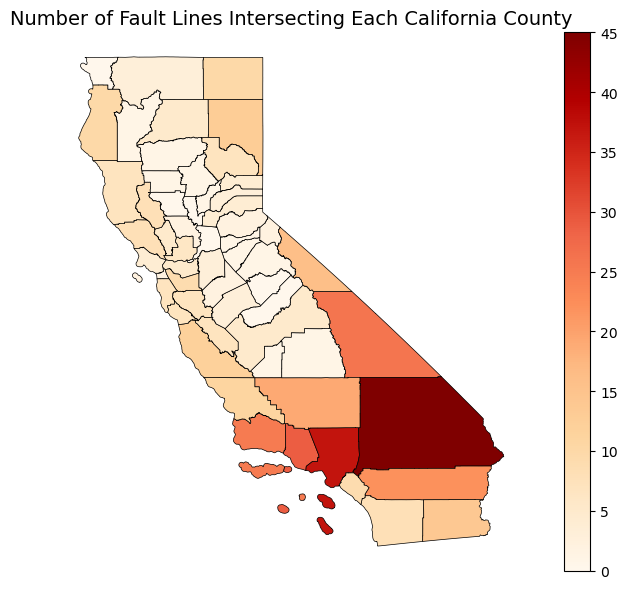

In [40]:
# Choropleth map of fault intersection counts by county
gdf_ca_extended.plot(
    column="n_faults_intersecting",
    cmap="OrRd",              # Orange-Red color scheme for risk intensity
    legend=True,              # Show legend
    edgecolor="black",        # County borders
    linewidth=0.5,            # Optional: thinner border
    figsize=(8, 6)
)

# Title and display settings
plt.title("Number of Fault Lines Intersecting Each California County", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()


---
### Distance-Based Features

Two distance-based features were engineered:  

1. `centroid_to_fault_km`: Distance from each county’s **centroid** to the nearest fault line  
2. `nearest_fault_km`: Distance from the **county boundary** (any point on the edge) to the nearest fault line  


In [42]:
# Reproject to a projected CRS (meters)
gdf_ca_proj = gdf_ca_extended.to_crs(epsg=3310)
gdf_faults_proj = gdf_faults_combined_final.to_crs(epsg=3310)


In [43]:
# Precompute fault line unary union (for efficiency)
faults_union = gdf_faults_proj.geometry.union_all()

# Calculate distance from centroid to nearest fault line (in meters → convert to km)
gdf_ca_proj["centroid_to_fault_km"] = (
    gdf_ca_proj.centroid.apply(lambda x: x.distance(faults_union)) / 1000
)

# Distance from county boundary (not centroid) to nearest fault
gdf_ca_proj["nearest_fault_km"] = (
    gdf_ca_proj.geometry.apply(lambda x: x.distance(faults_union)) / 1000
)

gdf_ca_proj[['county', 'centroid_to_fault_km', 'nearest_fault_km']].head(10)


,county,centroid_to_fault_km,nearest_fault_km
0,Sierra,7.548448,0.000000
1,Sacramento,39.106925,7.310129
2,Santa Barbara,2.211229,0.000000
3,Calaveras,11.081327,0.000000
4,Ventura,5.174008,0.000000
5,Los Angeles,2.190457,0.000000
6,Sonoma,12.160309,0.000000
7,Kings,12.191903,0.000000
8,San Diego,16.945166,0.000000
9,Placer,19.007856,0.000000


---
### Total Fault Length Within Each County

Fault line geometries were clipped to county boundaries to calculate the total length of fault lines within each county.  
This produced the feature:

- `fault_length_km`: Sum of fault line length inside each county  


In [45]:
# Clip faults by county boundaries (intersection)
faults_within_counties = gpd.overlay(gdf_faults_proj, gdf_ca_proj, how="intersection")

# Calculate length of each clipped segment (in km)
faults_within_counties["fault_length_km"] = faults_within_counties.geometry.length / 1000

# Summarize total fault length per county
fault_lengths_by_county = (
    faults_within_counties.groupby("county")["fault_length_km"].sum().reset_index()
)

# Merge summary back into county GeoDataFrame
gdf_ca_proj = gdf_ca_proj.merge(fault_lengths_by_county, on="county", how="left")

# Fill missing values (counties with no faults) with 0
gdf_ca_proj["fault_length_km"] = gdf_ca_proj["fault_length_km"].fillna(0)


In [46]:
# Top 10 counties by fault length
gdf_ca_proj.sort_values("fault_length_km", ascending=False)[["county", "fault_length_km"]].head(10)


,county,fault_length_km
23,San Bernardino,3092.920170
19,Inyo,1952.102984
5,Los Angeles,1852.805148
31,Riverside,1647.719211
57,San Luis Obispo,1322.692478
32,Kern,1144.292988
16,Monterey,885.538016
2,Santa Barbara,826.046416
20,Mono,824.128403
4,Ventura,746.626273


---
## 🧭 Fault Orientation Summary (Strike Direction)

The structural orientation of faults was summarized to capture tectonic characteristics at the county level.  

Two features were created:  
- **`mean_fault_azimuth_deg`** — average orientation angle (in degrees from North) of fault segments within the county  
- **`fault_orientation`** — compass-based categorical bin of the mean azimuth  

| Direction | Azimuth Range (°)      |
|-----------|------------------------|
| N–S       | 0–22.5 & 157.5–180     |
| NE–SW     | 22.5–67.5              |
| E–W       | 67.5–112.5             |
| NW–SE     | 112.5–157.5            |
| No Faults | NaN                    |

This directional encoding provided a simplified categorical summary of fault geometry, which can be useful for analyzing **rupture propagation risk**, **fault system behavior**, and **regional tectonic classification**.


In [48]:
def compute_azimuth(line):
    """
    Compute the azimuth (bearing) of a LineString or MultiLineString in degrees.
    Returns angle in range [0, 180], representing orientation (not direction).
    """
    if line.is_empty:
        return np.nan
    
    # For MultiLineString, compute azimuth for each sub-line and average
    if line.geom_type == 'MultiLineString':
        azimuths = [compute_azimuth(geom) for geom in line.geoms if geom.length > 0]
        return np.nanmean(azimuths) if azimuths else np.nan
    
    if line.geom_type != 'LineString' or len(line.coords) < 2:
        return np.nan
    
    # Use start and end coordinates
    x1, y1 = line.coords[0]
    x2, y2 = line.coords[-1]

    dx = x2 - x1
    dy = y2 - y1
    angle = np.degrees(np.arctan2(dy, dx))
    
    # Convert to azimuth range [0, 180]
    azimuth = abs(angle % 180)
    return azimuth


In [49]:
# Compute Azimuth for Each Segment
faults_within_counties["fault_azimuth"] = faults_within_counties.geometry.apply(compute_azimuth)

# Compute average fault orientation (azimuth) per county
# Group by county and calculate the mean azimuth of intersecting fault segments
azimuth_by_county = (
    faults_within_counties
    .groupby("county")["fault_azimuth"]
    .mean()
    .reset_index()
    .rename(columns={"fault_azimuth": "mean_fault_azimuth_deg"})
)

# Merge into main GeoDataFrame
gdf_ca_proj = gdf_ca_proj.merge(azimuth_by_county, on="county", how="left")


In [50]:
# Sort by fault length to surface high-risk counties
gdf_ca_proj[["county", "fault_length_km", "mean_fault_azimuth_deg"]].sort_values("fault_length_km", ascending=False).head(10)


,county,fault_length_km,mean_fault_azimuth_deg
23,San Bernardino,3092.920170,102.166875
19,Inyo,1952.102984,103.750747
5,Los Angeles,1852.805148,105.843117
31,Riverside,1647.719211,112.750215
57,San Luis Obispo,1322.692478,128.147605
32,Kern,1144.292988,94.364601
16,Monterey,885.538016,138.100598
2,Santa Barbara,826.046416,131.901849
20,Mono,824.128403,99.504049
4,Ventura,746.626273,83.014438


In [51]:
# Bin Fault Azimuth into Directional Categories
# Define function to bin azimuth into directional categories
def azimuth_to_orientation(azimuth):
    if pd.isna(azimuth):
        return "No Faults"
    elif (azimuth >= 0 and azimuth < 22.5) or (azimuth >= 157.5 and azimuth <= 180):
        return "N–S"
    elif azimuth >= 22.5 and azimuth < 67.5:
        return "NE–SW"
    elif azimuth >= 67.5 and azimuth < 112.5:
        return "E–W"
    elif azimuth >= 112.5 and azimuth < 157.5:
        return "NW–SE"
    else:
        return "Uncategorized"

# Apply to your DataFrame
gdf_ca_proj["fault_orientation"] = gdf_ca_proj["mean_fault_azimuth_deg"].apply(azimuth_to_orientation)

gdf_ca_proj[["county", "fault_length_km", "mean_fault_azimuth_deg", "fault_orientation"]].sort_values("fault_length_km", ascending=False).head(10)


,county,fault_length_km,mean_fault_azimuth_deg,fault_orientation
23,San Bernardino,3092.920170,102.166875,E–W
19,Inyo,1952.102984,103.750747,E–W
5,Los Angeles,1852.805148,105.843117,E–W
31,Riverside,1647.719211,112.750215,NW–SE
57,San Luis Obispo,1322.692478,128.147605,NW–SE
32,Kern,1144.292988,94.364601,E–W
16,Monterey,885.538016,138.100598,NW–SE
2,Santa Barbara,826.046416,131.901849,NW–SE
20,Mono,824.128403,99.504049,E–W
4,Ventura,746.626273,83.014438,E–W


In [52]:
# Reproject gdf_ca_proj to match gdf_ca_extended (EPSG:4269)
gdf_ca_proj_4269 = gdf_ca_proj.to_crs(gdf_ca_extended.crs)

# Select and merge
additional_features = gdf_ca_proj_4269[
    ["county", "centroid_to_fault_km", "nearest_fault_km", "fault_length_km", "mean_fault_azimuth_deg", "fault_orientation"]
]

# Merge into extended
gdf_ca_extended = gdf_ca_extended.merge(additional_features, on="county", how="left")


In [53]:
# Final verification: preview fault-related features for each county
gdf_ca_extended[[
    "county", "intersects_fault", "n_faults_intersecting", "faults_list",
    "centroid_to_fault_km", "nearest_fault_km", "fault_length_km",
    "mean_fault_azimuth_deg", "fault_orientation"
]].head()


,county,intersects_fault,n_faults_intersecting,faults_list,centroid_to_fault_km,nearest_fault_km,fault_length_km,mean_fault_azimuth_deg,fault_orientation
0,Sierra,True,4,"[Mohawk Valley fault zone, Polaris fault, Dog ...",7.548448,0.000000,107.437807,103.306002,E–W
1,Sacramento,False,0,[],39.106925,7.310129,0.000000,NaN,No Faults
2,Santa Barbara,True,25,"[Santa Cruz Island fault zone, Red Mountain fa...",2.211229,0.000000,826.046416,131.901849,NW–SE
3,Calaveras,True,1,[Foothills fault system],11.081327,0.000000,28.458140,123.746756,NW–SE
4,Ventura,True,29,"[Malibu Coast fault, Bailey fault, Chatsworth ...",5.174008,0.000000,746.626273,83.014438,E–W


In [54]:
# Top 5 counties with the most intersecting faults
gdf_ca_extended.sort_values("n_faults_intersecting", ascending=False)[[
    "county", "n_faults_intersecting", "fault_length_km", "fault_orientation"
]].head()


,county,n_faults_intersecting,fault_length_km,fault_orientation
23,San Bernardino,45,3092.920170,E–W
5,Los Angeles,37,1852.805148,E–W
4,Ventura,29,746.626273,E–W
19,Inyo,26,1952.102984,E–W
2,Santa Barbara,25,826.046416,NW–SE


---
## 💾 Export Final GeoDataFrame (v3)


In [56]:
# Check column order
gdf_ca_extended.columns

Index(['STATEFP', 'COUNTYFP', 'COUNTYNS', 'GEOID', 'GEOIDFQ', 'county',
       'NAMELSAD', 'LSAD', 'CLASSFP', 'MTFCC', 'CSAFP', 'CBSAFP', 'METDIVFP',
       'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON',
       'total_population', 'median_income', 'age_0_17', 'age_18_64',
       'age_65_up', 'age_0_17_pct', 'age_18_64_pct', 'age_65_up_pct',
       'below_poverty', 'below_poverty_pct', 'white_alone_pct',
       'black_alone_pct', 'american_indian_alone_pct', 'asian_alone_pct',
       'native_hawaiian_alone_pct', 'hispanic_pct', 'total_housing_units',
       'built_pre_1980', 'built_1980_1999', 'built_2000_up',
       'total_households', 'owner_occupied', 'renter_occupied', 'owner_pct',
       'renter_pct', 'for_rent_pct', 'rented_not_occupied_pct', 'for_sale_pct',
       'sold_not_occupied_pct', 'seasonal_pct', 'migrant_pct',
       'other_vacant_pct', 'median_home_value', 'eq_policies', 'eq_takeup_pct',
       'EQ_Zone', 'Region', 'Total_Direct_Liability_2018',
       'Direct_I

In [57]:
# Priority variables grouped by category 

cols_geo_id = [
    "county", "GEOID", "STATEFP", "COUNTYFP", "NAMELSAD", "LSAD",
    "geometry"
]

cols_demographics = [
    "total_population", "median_income",
    "age_0_17", "age_18_64", "age_65_up",
    "age_0_17_pct", "age_18_64_pct", "age_65_up_pct",
    "below_poverty", "below_poverty_pct",
    "white_alone_pct", "black_alone_pct", "american_indian_alone_pct",
    "asian_alone_pct", "native_hawaiian_alone_pct", "hispanic_pct"
]

cols_housing = [
    "total_housing_units", "built_pre_1980", "built_1980_1999", "built_2000_up",
    "total_households", "owner_occupied", "renter_occupied",
    "owner_pct", "renter_pct",
    "for_rent_pct", "rented_not_occupied_pct", "for_sale_pct",
    "sold_not_occupied_pct", "seasonal_pct", "migrant_pct", "other_vacant_pct",
    "median_home_value"
]

cols_insurance = [
    "eq_policies", "eq_takeup_pct",
    "EQ_Zone", "Region",
    "Total_Direct_Liability_2018", "Direct_Insured_PML_2018",
    "Modeled_Loss_Ratio_2018_pct",
    "New_Voluntary", "Renewed_Voluntary",
    "New_FAIR", "Renewed_FAIR",
    "Total_Homeowners_Policies", "homeowners_coverage_pct",
    "fema_funding_earthquake"
]

cols_faults = [
    "intersects_fault", "n_faults_intersecting", "faults_list",
    "centroid_to_fault_km", "nearest_fault_km",
    "fault_length_km", "mean_fault_azimuth_deg", "fault_orientation"
]

cols_other_meta = [
    "COUNTYNS", "GEOIDFQ", "CLASSFP", "MTFCC", "CSAFP", "CBSAFP", "METDIVFP",
    "FUNCSTAT", "ALAND", "AWATER", "INTPTLAT", "INTPTLON"
]

# Final ordered column list
cols_ordered = (
    cols_geo_id +
    cols_demographics +
    cols_housing +
    cols_insurance +
    cols_faults +
    cols_other_meta
)

# Reorder dataframe 
cols_ordered = [col for col in cols_ordered if col in gdf_ca_extended.columns]  # filter out missing
gdf_ca_extended = gdf_ca_extended[cols_ordered]

gdf_ca_extended.head()


,county,GEOID,STATEFP,COUNTYFP,NAMELSAD,LSAD,geometry,total_population,median_income,age_0_17,...,CLASSFP,MTFCC,CSAFP,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON
0,Sierra,06091,06,091,Sierra County,06,"POLYGON ((-120.55587 39.50874, -120.55614 39.5...",2731,60000,349.0,...,H1,G4020,None,None,None,A,2468694578,23299110,+39.5769252,-120.5219926
1,Sacramento,06067,06,067,Sacramento County,06,"POLYGON ((-121.43991 38.25553, -121.44002 38.2...",1584047,88724,365667.0,...,H1,G4020,472,40900,None,A,2500063005,75323439,+38.4501363,-121.3443291
2,Santa Barbara,06083,06,083,Santa Barbara County,06,"MULTIPOLYGON (((-120.58226 34.10752, -120.5790...",443975,95977,99608.0,...,H1,G4020,None,42200,None,A,7080874935,2729198796,+34.5366774,-120.0383645
3,Calaveras,06009,06,009,Calaveras County,06,"POLYGON ((-120.6318 38.34603, -120.63066 38.34...",45995,79877,7768.0,...,H1,G4020,None,None,None,A,2641829627,43797225,+38.1910682,-120.5541065
4,Ventura,06111,06,111,Ventura County,06,"MULTIPOLYGON (((-119.63607 33.28071, -119.6348...",838259,107327,185795.0,...,H1,G4020,348,37100,None,A,4767585000,947376202,+34.3587477,-119.1331453


In [58]:
# Save final extended GeoDataFrame (v3 includes fault line features)
gdf_ca_extended.to_file("../output/gdf_ca_extended_v3.geojson", driver="GeoJSON")
gdf_ca_extended.to_csv("../output/gdf_ca_extended_v3.csv", index=False)

# Save 'faults_list' separately (GeoJSON doesn't support list objects)
faults_list_col = gdf_ca_extended[["county", "faults_list"]].copy()
faults_list_col.to_csv("../output/_temp_faults_list.csv", index=False)

print("✅ gdf_ca_extended saved as GeoJSON + CSV (v3) — faults_list exported separately")


✅ gdf_ca_extended saved as GeoJSON + CSV (v3) — faults_list exported separately


---

### 🖋️ Author & Attribution

This notebook is part of the **Earthquake Insurance Risk Analysis in California** project.  
Created and maintained by **Anna Piterskaya**  
Aspiring Data Scientist | Geospatial & Risk Modeling | [GitHub: annapiter](https://github.com/annapiter)

© 2025 Anna Piterskaya. All rights reserved.

📄 This work is licensed under the **Creative Commons Attribution-NonCommercial 4.0 International License**.  
You may share or adapt this work **with attribution** and **non-commercial use only**.  
🔗 [View License Details](https://creativecommons.org/licenses/by-nc/4.0/)
